## CMPINF 2100 Week 07
### Review boxplot

Although we will review, we will also discuss the LIMITATIONS of boxplots!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read data

In [2]:
gap_url = 'https://raw.githubusercontent.com/chendaniely/pandas_for_everyone/master/data/gapminder.tsv'

In [3]:
gap_df = pd.read_csv(gap_url, sep = '\t' )

In [4]:
gap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


## Boxplot
The boxplot is an excellent graphical tool for exploring CONDITIONAL DISTRIBUTIONS or RELATIONSHIPS between categorical and continuous variables

In Seaborn, it is part of the 'sns.catplot()' FIGURE LEVEL function

The categorical variable is usually associated with the 'x' axis and the continuous variable is usually associated with the 'y' axis.

The BOXPLOT summarizes the CONDITIONAL DISTIBUTION withe SEVERAL summary statistics

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


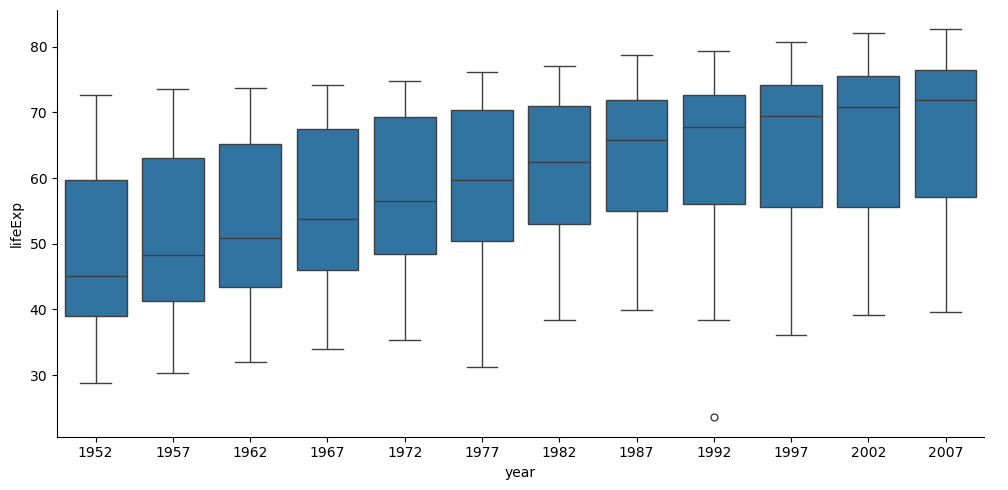

In [11]:
sns.catplot(data = gap_df, x='year', y='lifeExp', kind='box', aspect=2 )
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


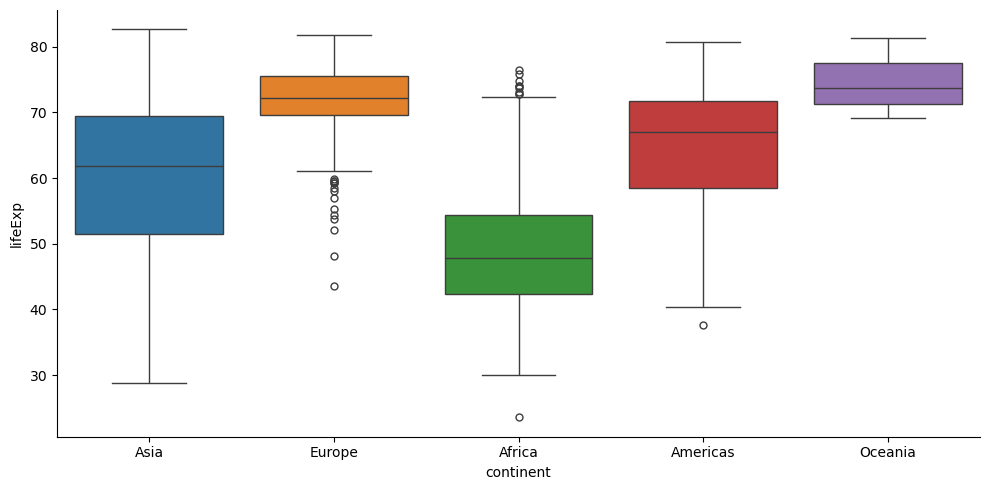

In [13]:
sns.catplot( data = gap_df, x = 'continent', y='lifeExp', kind='box', hue = 'continent', aspect=2)
plt.show()

In summary, boxplots allow us to answer several IMPORTANT questions:
* Does the MEDIAN appear to change across categories?
* Does the VARIATION appear to change across the categories?
* More generally, are the summary statistics different across the categories?

## What is the boxplot best suited for?
A boxplot is at its best when the CONDITIONAL DISTRIBUTION are roughly SYMMETRIC

That means we must check the shape of the conditional distributions!!!

One way to do that is with FACETED histograms!!!

Let's return to the CONDITIONAL DISTRIBUTION of 'lifeExp' **GIVEN** 'year'

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


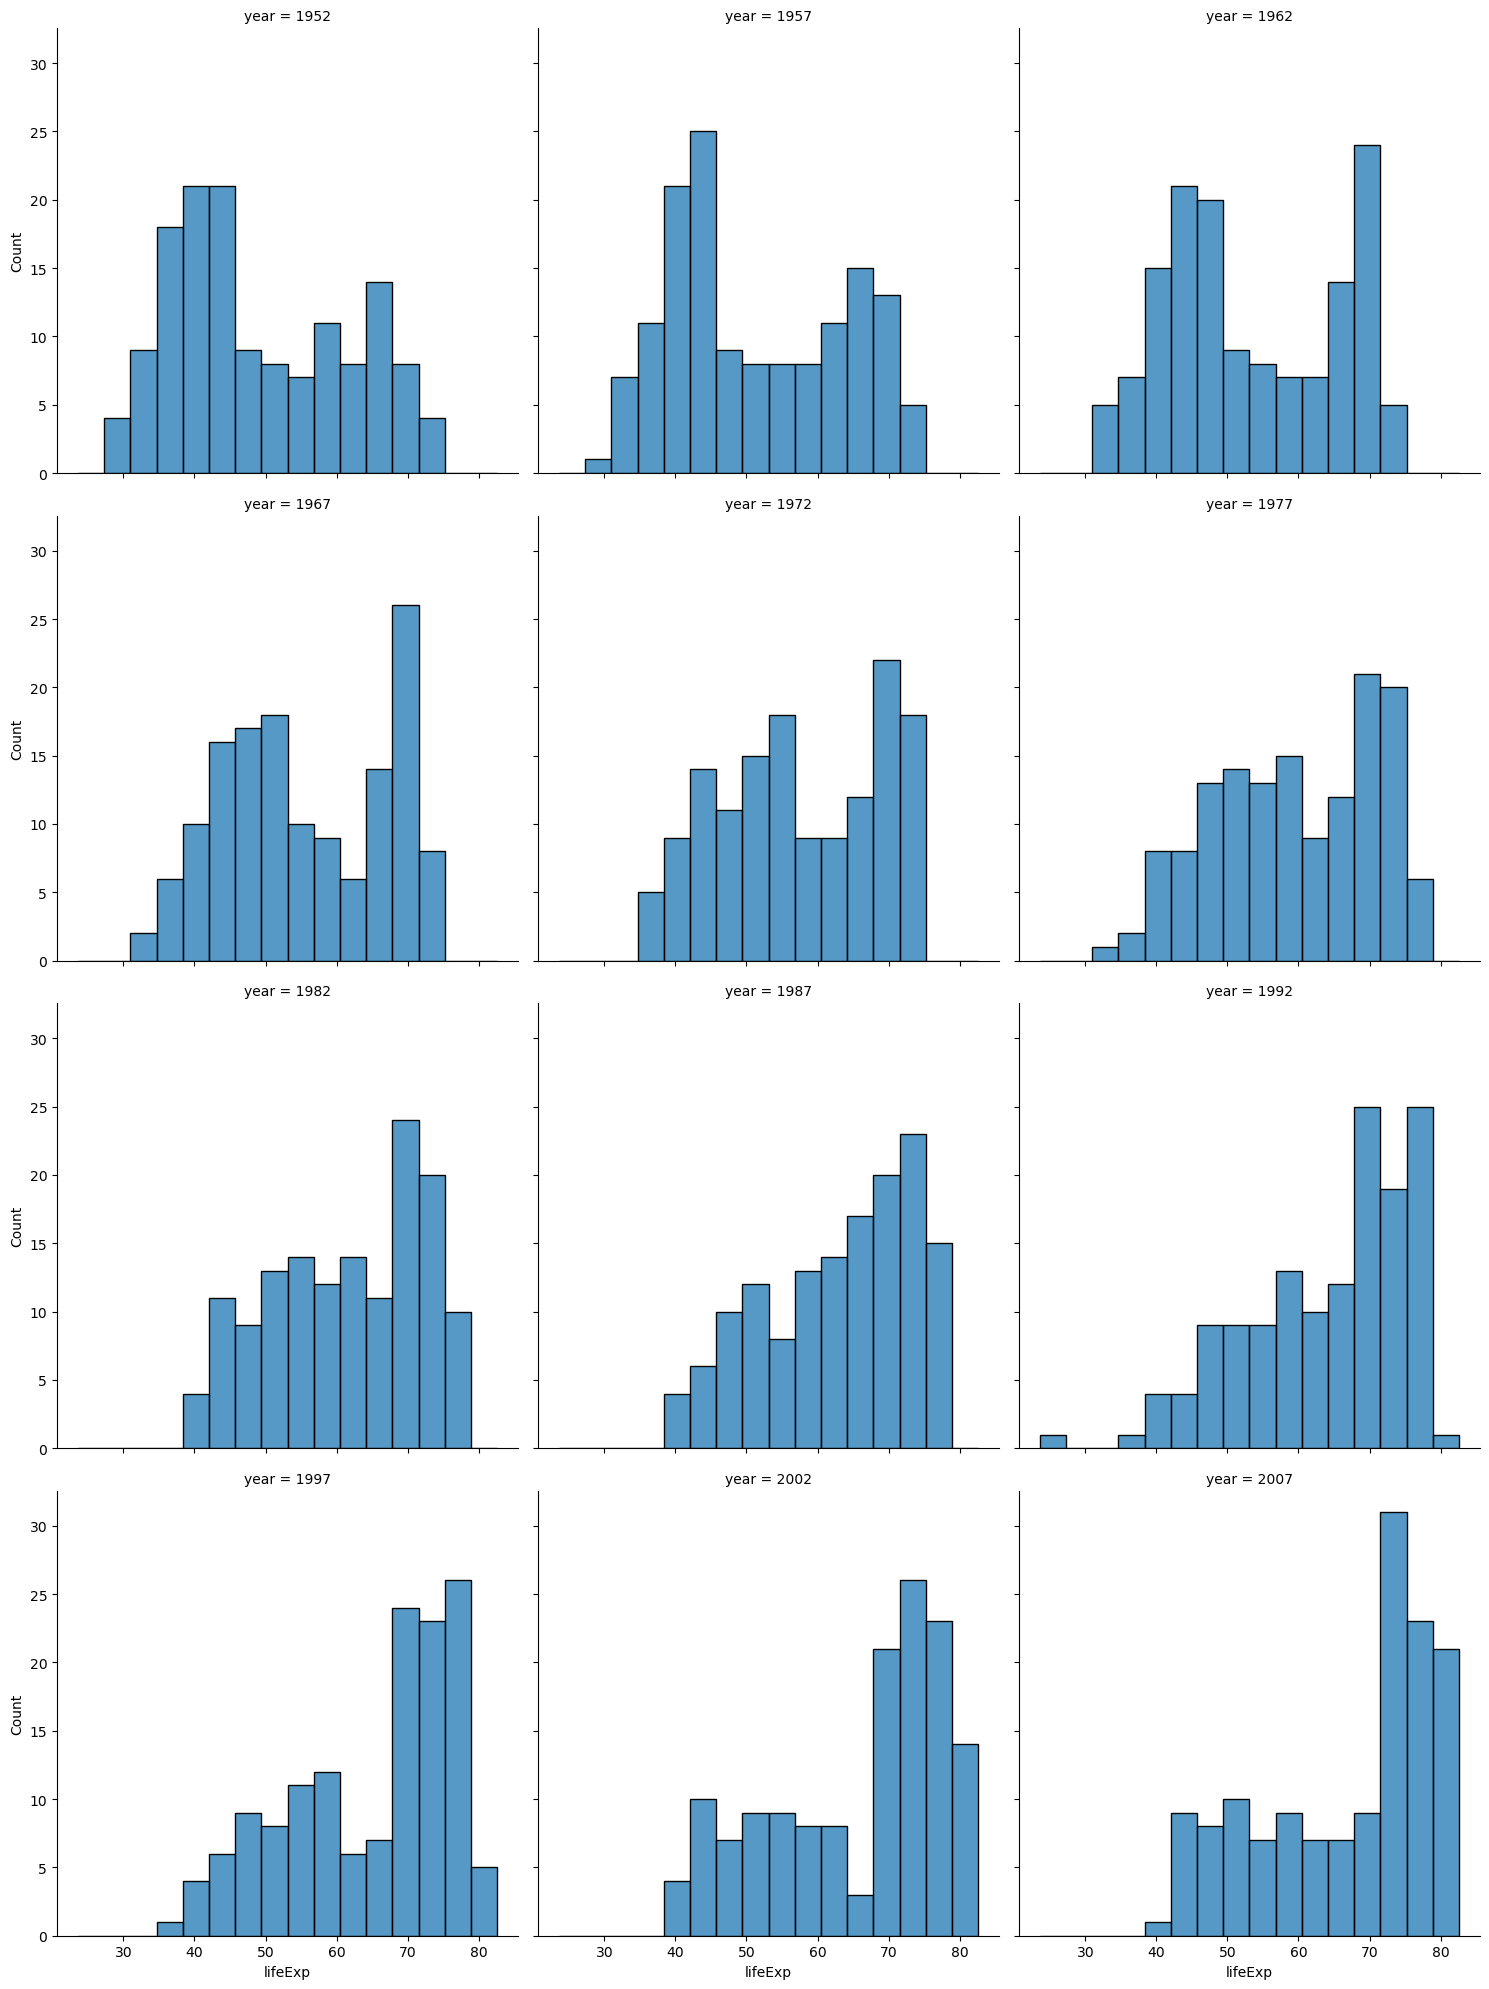

In [16]:
sns.displot( data = gap_df, x='lifeExp', col='year', col_wrap=3)
plt.show()

None of the facets show EXTREME lack of symmetry!!!

Lack of symmetry  is referred to as a SKEW.

What does EXTREME SKEW look like? And what are the consequences of EXTREME skew???

Load in a dataset that has Extreme SKEW

In [17]:
diamonds = sns.load_dataset('diamonds')

In [18]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [19]:
diamonds.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [20]:
diamonds.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

In [21]:
diamonds.dtypes.value_counts()

float64     6
category    1
category    1
category    1
int64       1
Name: count, dtype: int64

In [22]:
diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [23]:
diamonds.nunique()

carat        273
cut            5
color          7
clarity        8
depth        184
table        127
price      11602
x            554
y            552
z            375
dtype: int64

The category data type is a SPECIAL data type for CATEGORICAL VARIABLES within Pandas

In [25]:
diamonds.color.value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [27]:
diamonds.color.value_counts(normalize=True)

color
G    0.209344
E    0.181628
F    0.176900
H    0.153949
D    0.125603
I    0.100519
J    0.052058
Name: proportion, dtype: float64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


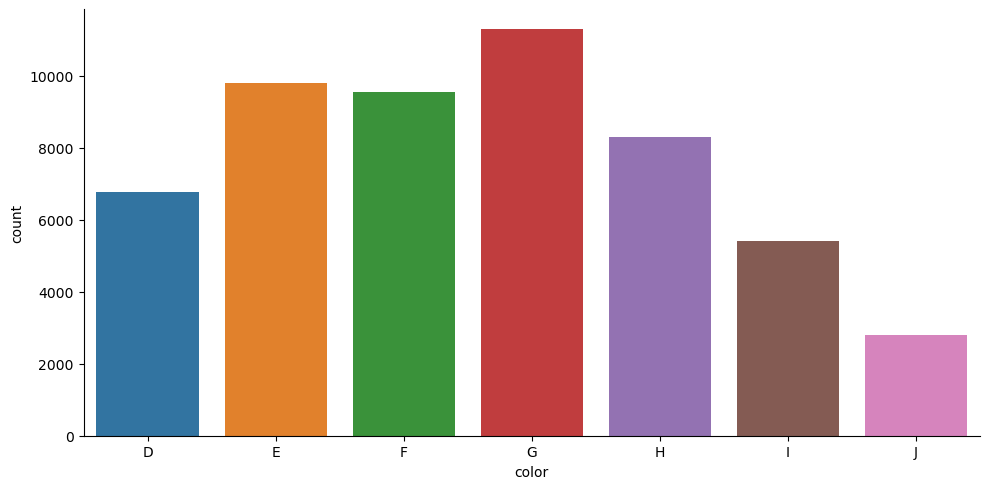

In [30]:
sns.catplot(data = diamonds, x='color', kind='count', hue='color', aspect=2)
plt.show()

Let's now examine a MARGINAL DISTRIBUTION of the continuous variable price

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


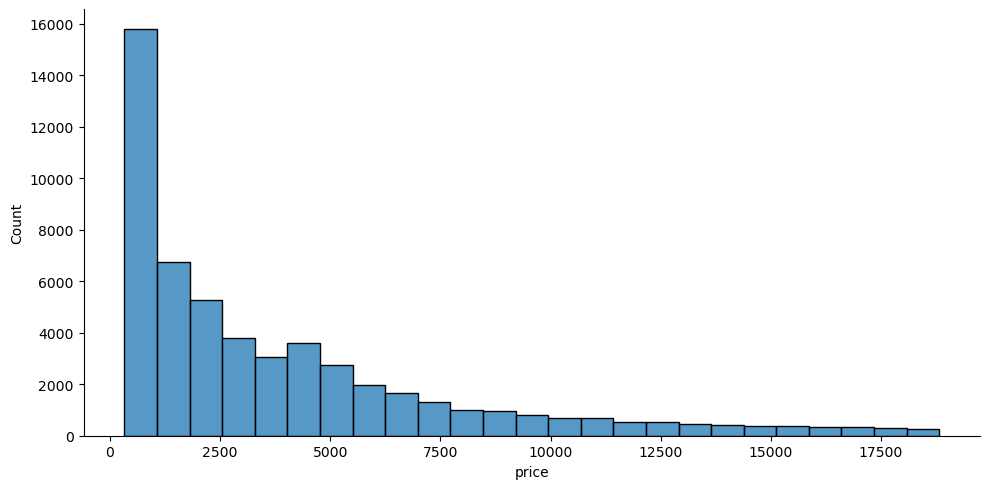

In [32]:
sns.displot(data = diamonds, x='price', bins=25, aspect=2)
plt.show()

Higly skewed 
Include the KDE on top of the histgram to get a SMOOTHER picture of the distribution

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


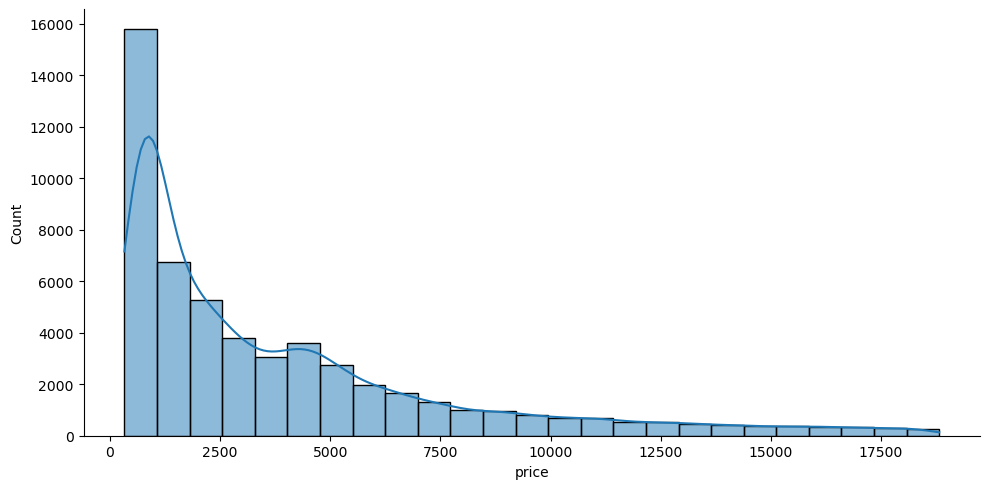

In [36]:
sns.displot(data = diamonds, x='price', bins=25, kde=True, aspect=2)
plt.show()

Let's now examine the CONDITIONAL DISTRIBUTION of price GIVEN color
We will visualize the categories via facets

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


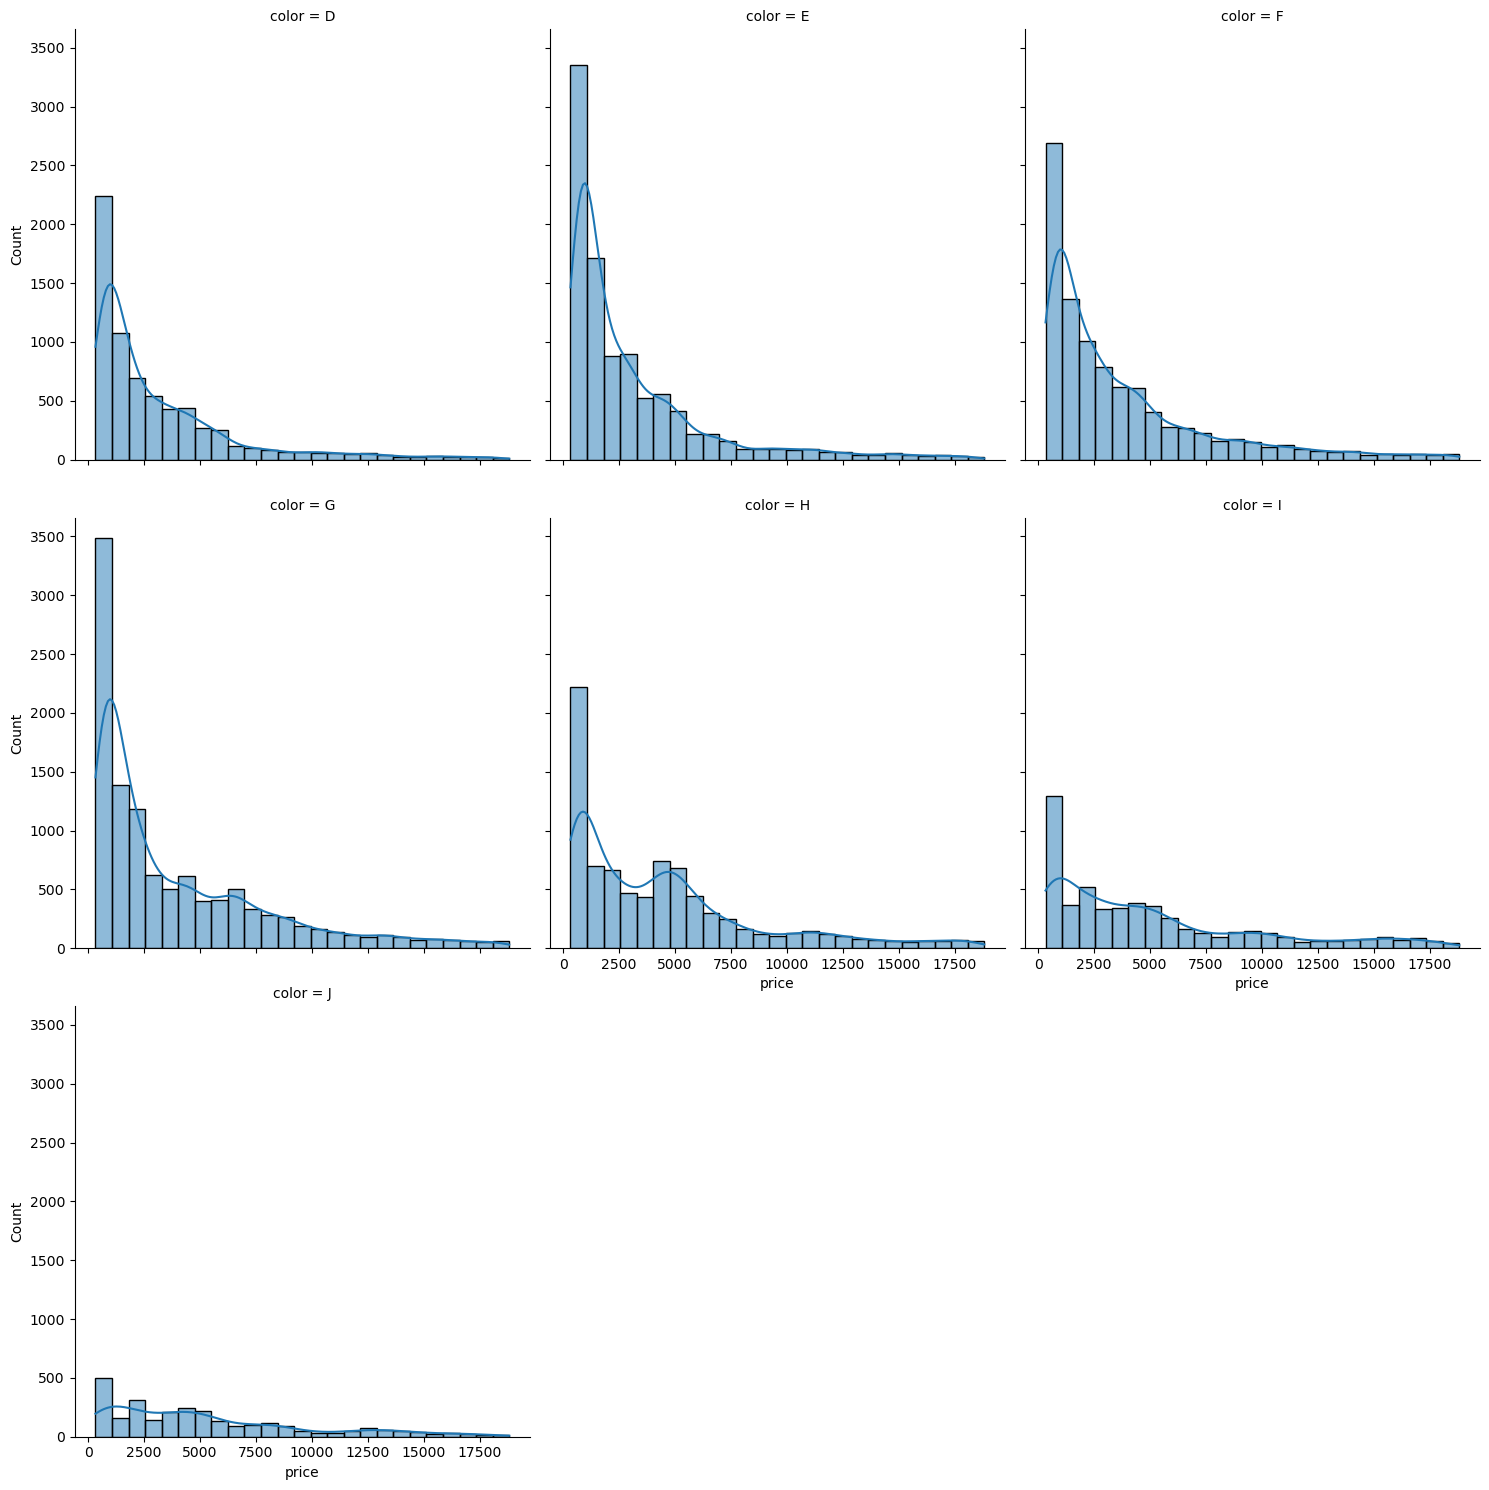

In [39]:
sns.displot(data = diamonds, x='price', col='color', bins=25, kde=True, col_wrap=3)
plt.show()

By default ALL facets SHARE the x and y axis bounds!

Sometimes we need to MODIFY the bounds to allow them to be NOT SHARED or FREE!

Let's change the y axis bounds to be FREE in the conditional distribution figure

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


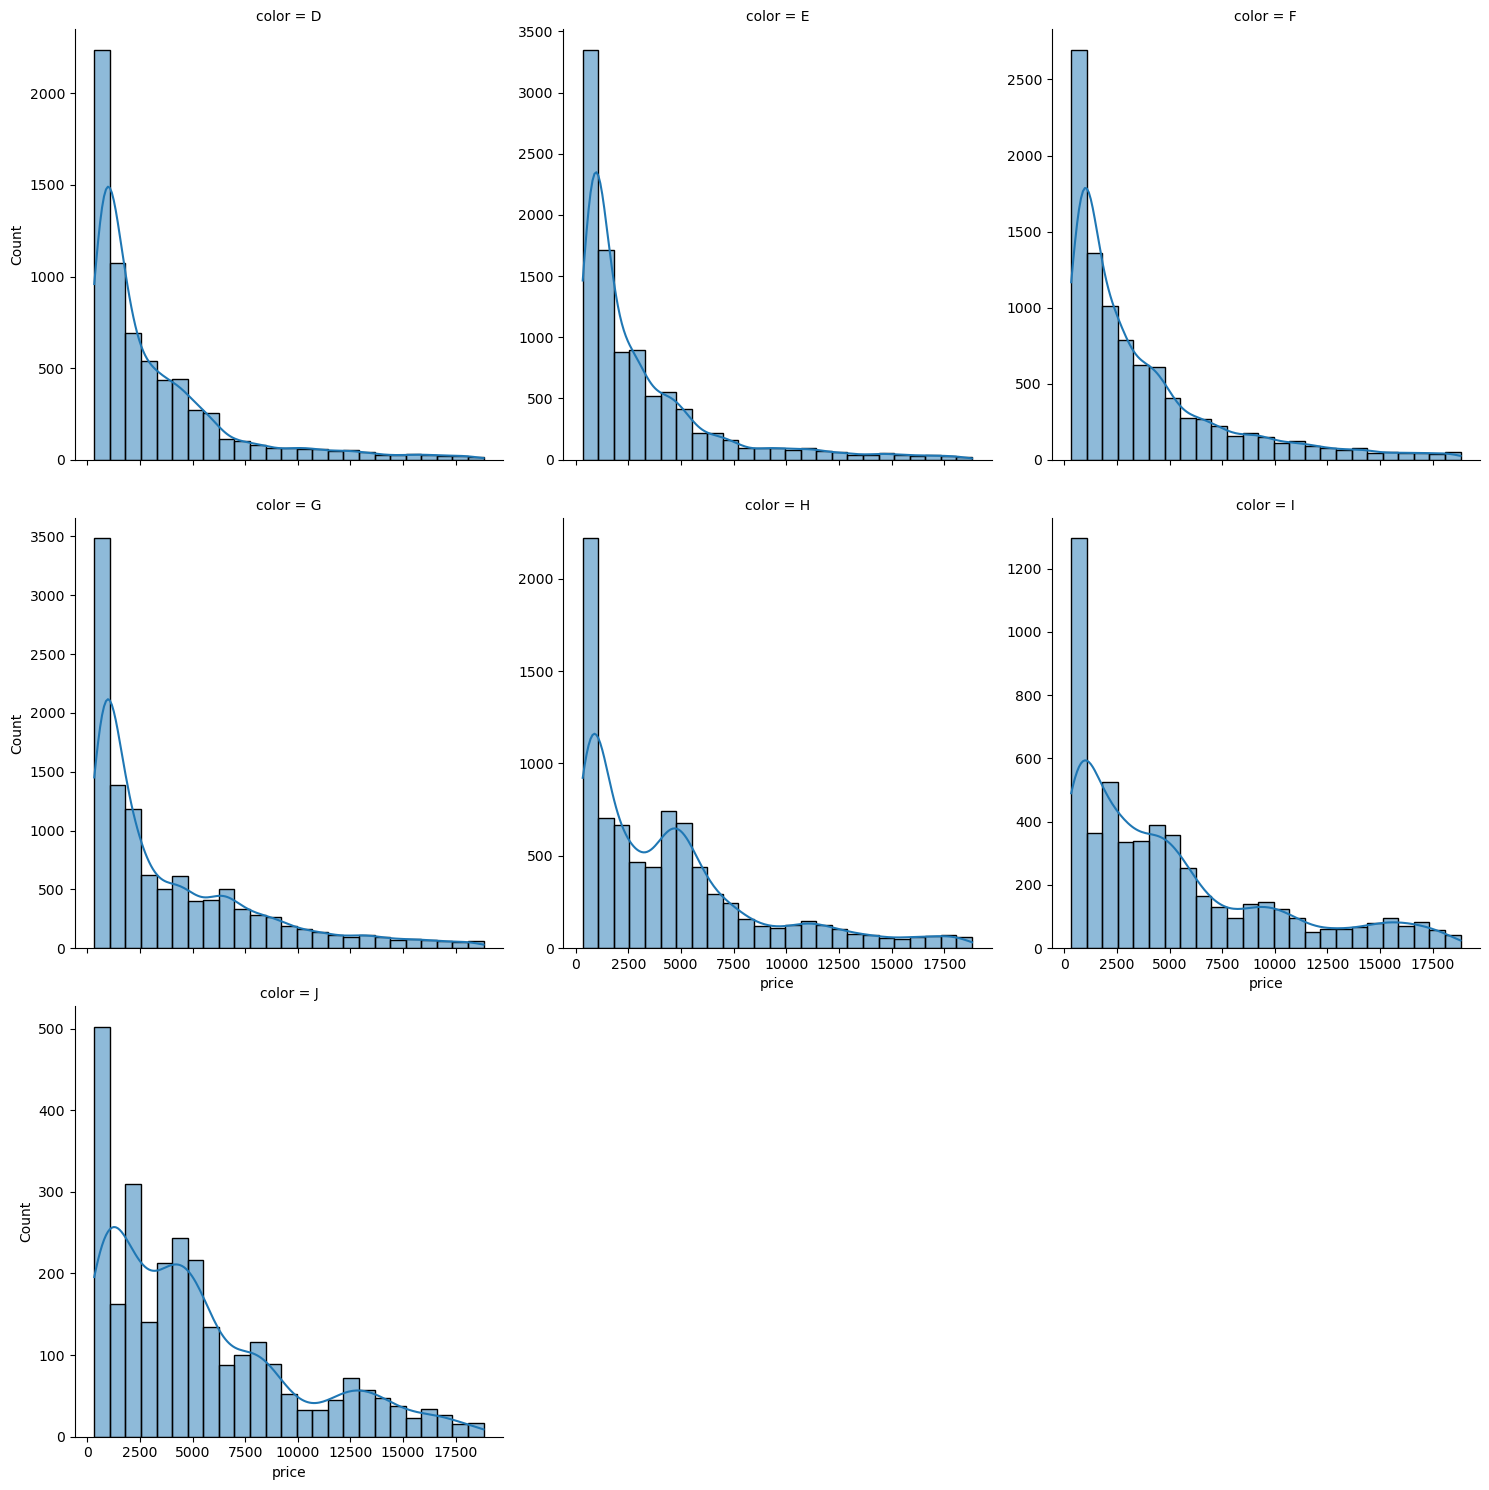

In [41]:
sns.displot(data = diamonds, x='price', col='color', bins=25, kde=True, col_wrap=3,
           facet_kws={'sharey': False})
plt.show()

Note that the count on the y axis is different for the plots now

What is the consequence of the SKEW or LONG TAIL behavior on the BOXPLOT???

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


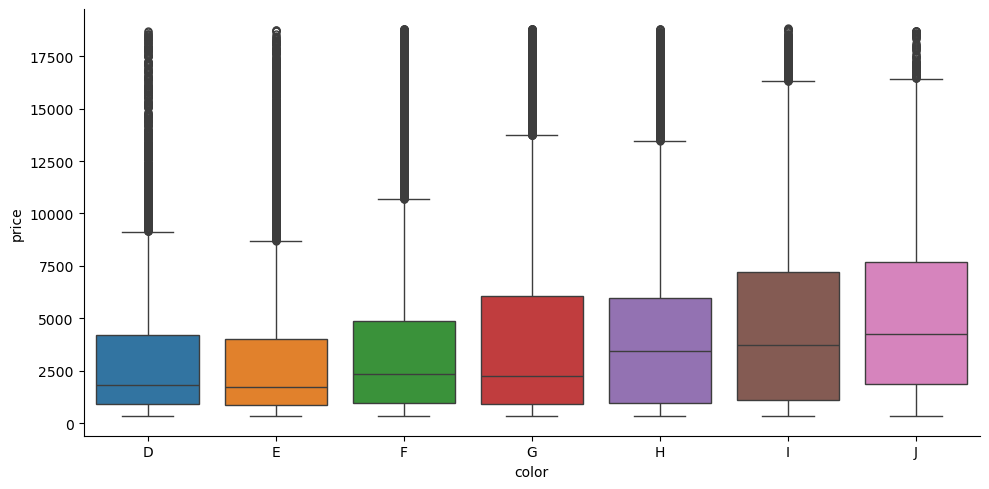

In [43]:
sns.catplot( data = diamonds, x='color', y='price', kind='box', hue='color', aspect=2)
plt.show()

Are the most FREQUENT values or...are the MOST FREQUENT INTERVALS....contained in the BOXES???

EXTREMELY SKEWED distributions will have the MOST FREQUENT INTERVALS near the LOWER or UPPER bounds!!!

The boxplot CANNOT represent that behavior because BOXPLOT CANNOT show the DISTRIBUTION SHAPE!!!

We can see the shape with FACETED HISTOGRAM (KDE plots)...but a draw back of FACETS...is we have to look at MANY subplots!!!

What if used CONDITIONAL KDE plots...with the categorical variables associated with the 'hue' argumnet???

Set common_norm=False to remove the sample size effect

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


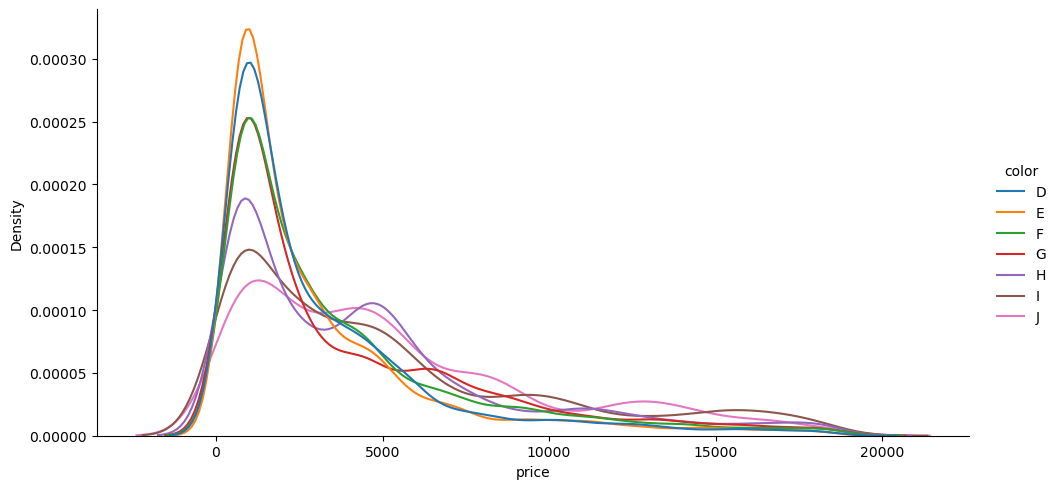

In [45]:
sns.displot(data = diamonds, x='price', hue='color', kind='kde', common_norm=False, aspect=2)
plt.show()

CONDITIONAL KDE plots can be VERY BUSY to look at when we have more than 4 categories!!!

## Violin Plot
The Violin plot shows  CONDITIONAL KDE plots SIDE by SIDE within a single AXIS rather than across multiple subplots!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


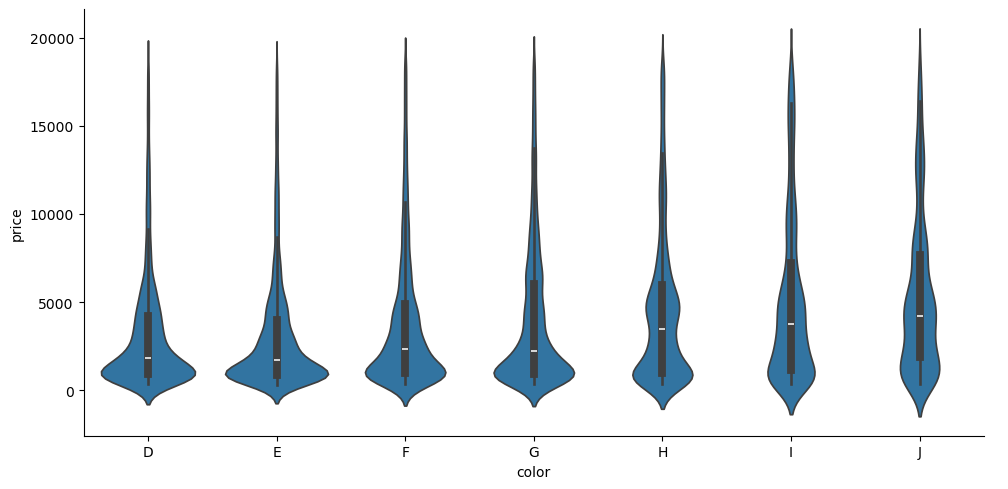

In [60]:
sns.catplot( data = diamonds, x='color', y='price', kind='violin', aspect=2)
plt.show() 

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


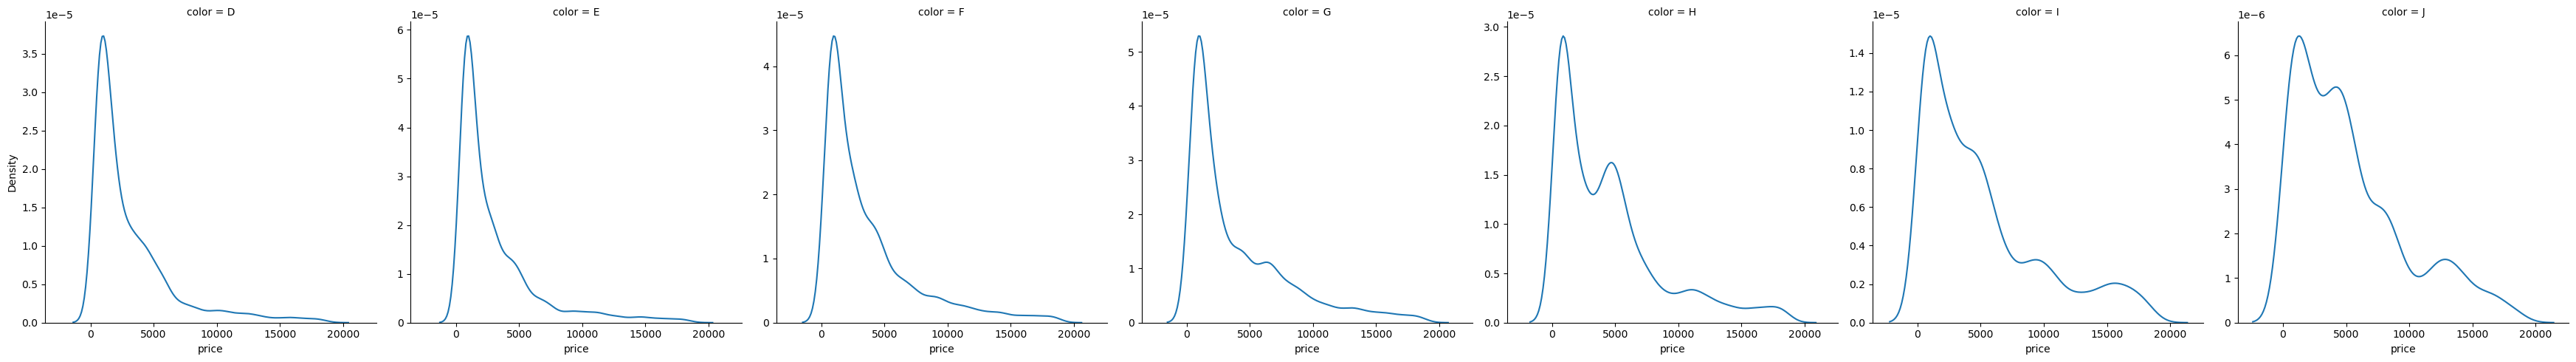

In [50]:
sns.displot(data = diamonds, x='price', col='color', kind='kde',
           facet_kws={'sharey': False})
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


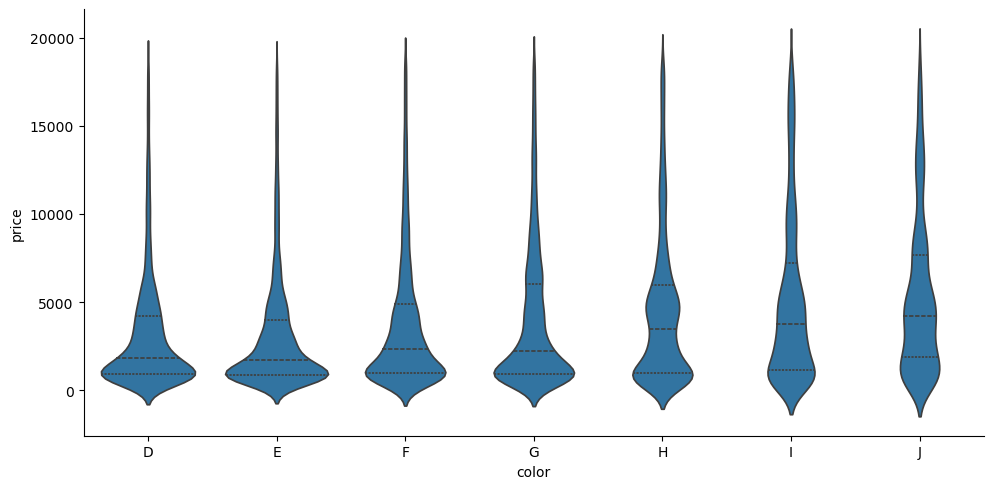

In [56]:
sns.catplot( data = diamonds, x='color', y='price', kind='violin', aspect=2,
            inner='quartile')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


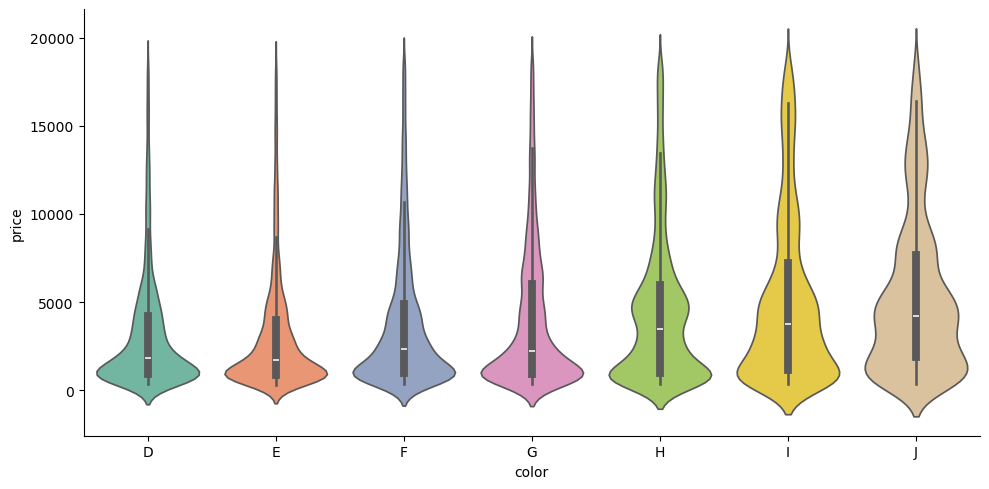

In [62]:
sns.catplot(data=diamonds, x='color', y='price', kind='violin', 
            aspect=2, hue='color', legend=False, palette='Set2')
plt.show()

In summary 
* Always look at a boxplot to study how the summary statistics CHANGE across categories
* But you must ALSO look at if the distributional SHAPE is SYMMETRIC and if the distributional shape CHANGES across categoreis!
* * Use faceted histogram/kde plots
  * Use violin plots

Go back to the GAP MINDER data set

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


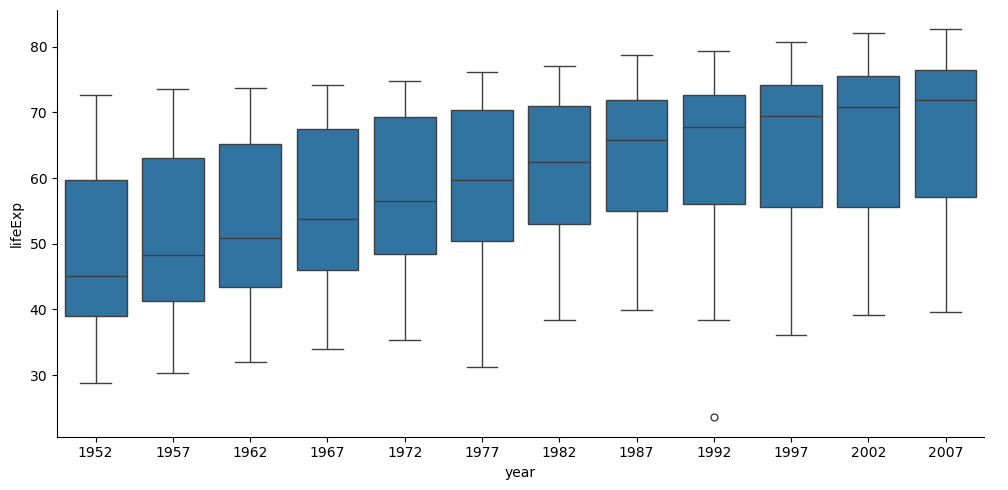

In [64]:
sns.catplot( data = gap_df, x='year', y='lifeExp', kind='box', aspect=2)
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


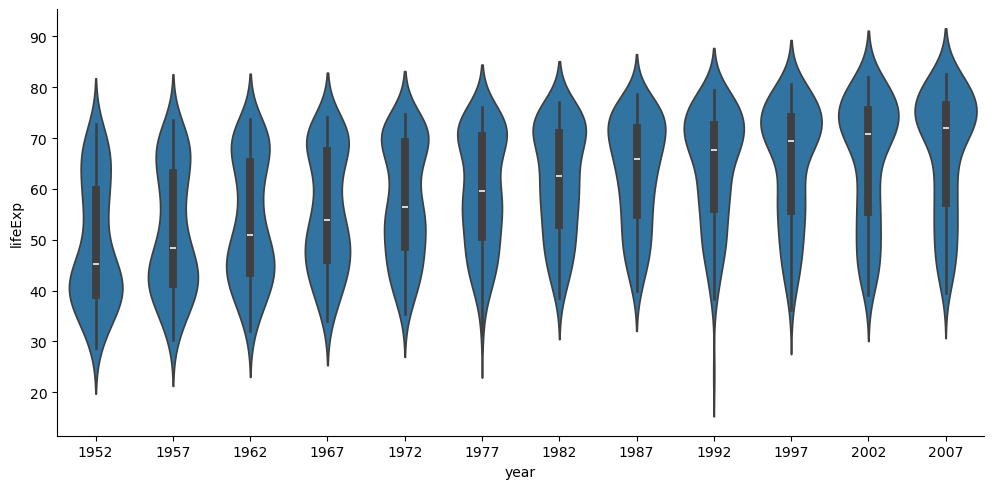

In [65]:
sns.catplot( data = gap_df, x='year', y='lifeExp', kind='violin', aspect=2)
plt.show()